# Loss fonksiyonu & optimizer

In [30]:
import torch
print(torch.__version__)

2.11.0+cpu


In [31]:
#Kütüphaneler: torch → temel işlemler, nn → model kurma, optim → öğrenme (optimizer)
import torch
import torch.nn as nn
import torch.optim as optim

# veri (y = 2x + 1)
x = torch.unsqueeze(torch.linspace(-1, 1, 100), dim=1) # X: -1 ile 1 arasında 100 sayı üretir
y = 2 * x + 1  # Y: modelin öğrenmesi gereken şey

# model
model = nn.Linear(1, 1)
# Aslında şunu yapar: y = wx + b   w (weight) = rastgele, b (bias) = rastgele    yani model başta saçmalar

# loss + optimizer
loss_fn = nn.MSELoss()   # modelin ne kadar yanlış olduğunu ölçer
optimizer = optim.Adam(model.parameters(), lr=0.1)     # modelin içindeki: weight (w) bias (b)  bunları değiştirir

loss_list = [] # Boş bir liste (kutu) oluşturuyor

# training
for epoch in range(50):      #50 kere öğrenmeye çalışır
    y_pred = model(x)        #Tahmin
    loss = loss_fn(y_pred, y) #Hata hesapla

    optimizer.zero_grad()      #Eski bilgiyi temizle
    loss.backward()            #Geri yayılım-hangi yönde düzeltmeliyim?
    optimizer.step()            #Güncelle

    loss_list.append(loss.item())

    if epoch % 10 == 0:    #her 10 adımda hatayı görürsün
        print(loss.item())

2.1127686500549316
0.6857534646987915
0.10093425959348679
0.0003270902088843286
0.018343664705753326


In [32]:
# Modelin içindeki parametreleri (ağırlıkları) yazdırır
for name, param in model.named_parameters():
    print(name, param.data)

weight tensor([[2.1720]])
bias tensor([0.9819])


loss → hatayı ölçtü
optimizer → düzeltti
loop → tekrar etti

In [33]:
import matplotlib.pyplot as plt

In [34]:
!pip install matplotlib

In [35]:
import matplotlib.pyplot as plt
print("ok")

ok


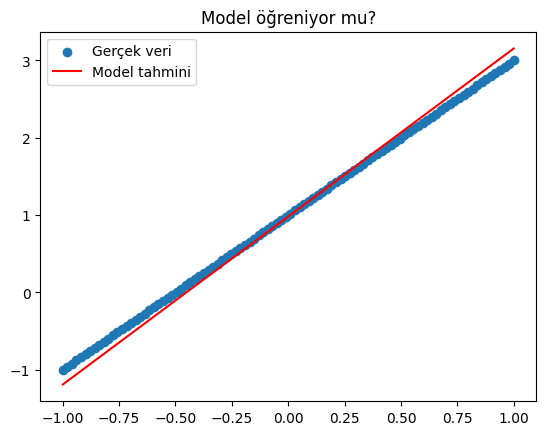

In [36]:
import matplotlib.pyplot as plt

# model tahmini
y_pred = model(x).detach().numpy()

# gerçek veri
x_np = x.numpy()
y_np = y.numpy()

# çizim
plt.scatter(x_np, y_np, label="Gerçek veri")
plt.plot(x_np, y_pred, color='red', label="Model tahmini")

plt.legend()
plt.title("Model öğreniyor mu?")
plt.show()

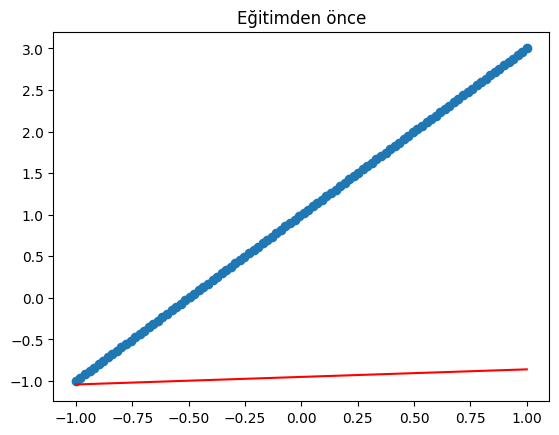

In [37]:
# eğitimden önce
model = nn.Linear(1,1)
y_pred_before = model(x).detach().numpy()

plt.scatter(x.numpy(), y.numpy())
plt.plot(x.numpy(), y_pred_before, color='red')
plt.title("Eğitimden önce")
plt.show()

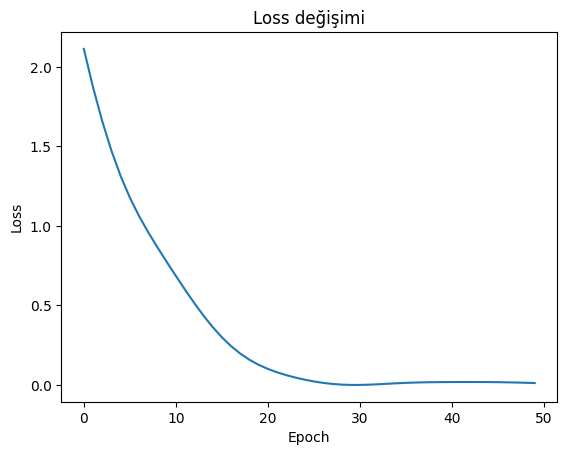

In [38]:
import matplotlib.pyplot as plt

plt.plot(loss_list)
plt.title("Loss değişimi")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [39]:
print(len(loss_list))

50
